# Лабораторна робота №3 “Кластеризація”
**Мета.** Ознайомитися з методами **кластеризації** (clustering) на прикладі реального набору музичних даних **Spotify Tracks Dataset**. Навчитись підбирати оптимальну кількість кластерів (k) за допомогою методу ліктя **(elbow)**, виконувати кластеризацію методом **K-Means**, знижувати розмірність простору ознак за допомогою **PCA** для візуалізації та аналізувати характеристики утворених кластерів. 

## 1. Завантаження та підготовка даних
Завантажимо необхідні бібліотеки.

In [1]:
import os
import pandas as pd
import kagglehub
from sklearn.preprocessing import StandardScaler

Встановимо датасет, якщо він ще не існує.

In [2]:
dataset_path = "./tmp/lab3/SpotifyFeatures.csv"
if not os.path.exists(dataset_path):
    kagglehub.dataset_download("zaheenhamidani/ultimate-spotify-tracks-db", output_dir="./tmp/lab3")
    print("download complete")

Зчитаємо файл і перетворимо його у Dataframe. Виведемо перші 5 рядків та статистику колонок.

In [3]:
df = pd.read_csv(dataset_path)
df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [4]:
df.describe()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


Виконаємо стандартизацію числових ознак.

In [5]:
features = [
    "acousticness", "danceability", "energy", "loudness", 
    "speechiness", "instrumentalness", "liveness", 
    "valence", "tempo", "duration_ms", "popularity"
]

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])
df_scaled.describe()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,2.327250e+05,232725.000000,2.327250e+05,2.327250e+05,2.327250e+05,232725.000000,2.327250e+05,2.327250e+05,232725.000000,2.327250e+05,2.327250e+05
mean,3.908023e-17,0.000000,-6.252837e-17,-1.954012e-17,-3.829863e-16,0.000000,-1.328728e-16,-9.379256e-17,0.000000,-7.034442e-17,-2.090792e-16
std,1.000002e+00,1.000002,1.000002e+00,1.000002e+00,1.000002e+00,1.000002,1.000002e+00,1.000002e+00,1.000002,1.000002e+00,1.000002e+00
min,-2.261007e+00,-1.038880,-2.680191e+00,-1.847514e+00,-2.167115e+00,-0.489819,-1.035644e+00,-7.150008e+00,-0.531296,-2.824947e+00,-1.749243e+00
25%,-6.667160e-01,-0.932895,-6.431004e-01,-4.394421e-01,-7.058423e-01,-0.489819,-5.931709e-01,-3.669631e-01,-0.453137,-7.996282e-01,-8.379325e-01
50%,1.029416e-01,-0.384930,8.962731e-02,-1.235571e-01,1.292150e-01,-0.489672,-4.388376e-01,3.014051e-01,-0.380907,-6.112155e-02,-4.197743e-02
75%,7.626480e-01,0.996257,7.415395e-01,2.576659e-01,8.200350e-01,-0.371576,2.470882e-01,6.783521e-01,-0.084978,6.921753e-01,7.885844e-01
max,3.236547e+00,1.768595,2.341688e+00,4.471153e+01,1.624727e+00,2.809741,3.959158e+00,2.219650e+00,4.561473,4.053111e+00,2.095950e+00


## 2. Підбір оптимальної кількості кластерів (k) — метод ліктя

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

Знайдемо суму квадратів відстаней для 2-15 кластерів.

In [7]:
inertia = []
k_range = range(2, 16)

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(df_scaled[features])
    inertia.append(kmeans.inertia_)  # Сума квадратів відстаней

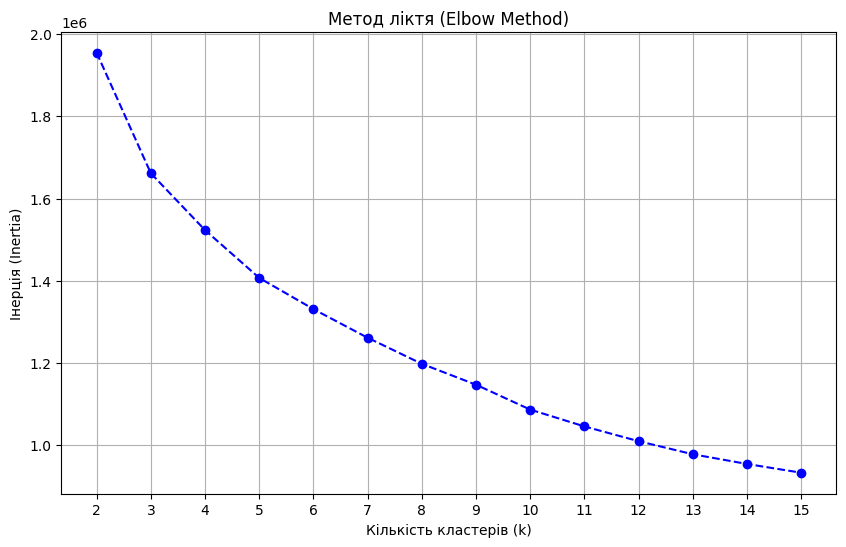

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', color='b', linestyle='--')
plt.title('Метод ліктя (Elbow Method)')
plt.xlabel('Кількість кластерів (k)')
plt.ylabel('Інерція (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

Оскільки наш датасет достатньо великий, і природа музики дозволяє багато "перехідних" станів, чіткого "зламу" немає, проте для лабораторної роботи оберемо кількість кластерів k = 6.

## 3. Побудова кластеризації

In [9]:
import numpy as np

Побудуємо кластеризацію.

In [10]:
k_optimal = 6
kmeans = KMeans(n_clusters=k_optimal, n_init=10, random_state=42)
df['cluster'] = kmeans.fit_predict(df_scaled[features])

Виведемо кількість треків за кластерами.

In [11]:
print("Розподіл треків за кластерами:")
print(df['cluster'].value_counts())

Розподіл треків за кластерами:
cluster
1    59661
2    57403
0    46742
4    32907
5    25952
3    10060
Name: count, dtype: int64


## 4. Візуалізація кластерів у просторі головних компонент
Для того, щоб візуалізувати кластери у двовимірному просторі, використаємо метод головних компонент для зменшення розмірності даних.

In [12]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

Використаємо метод головних компонент.

In [13]:
pca = PCA(n_components=2)
pca_results = pca.fit_transform(df_scaled[features])
df['pca1'] = pca_results[:, 0]
df['pca2'] = pca_results[:, 1]

Виведемо пояснену дисперсію (може знадобитися в подальшому аналізі).

In [14]:
explained_variance = pca.explained_variance_ratio_

print("Відсоток поясненої дисперсії для кожної компоненти:")
for i, variance in enumerate(explained_variance):
    print(f"Головна компонента {i+1} (PC{i+1}): {variance:.2%}")

print(f"\nЗагальний відсоток поясненої дисперсії: {np.sum(explained_variance):.2%}")

Відсоток поясненої дисперсії для кожної компоненти:
Головна компонента 1 (PC1): 32.82%
Головна компонента 2 (PC2): 15.55%

Загальний відсоток поясненої дисперсії: 48.37%


Відфільтруємо непопулярні треки (popularity < 85).

In [15]:
df_filtered = df[df["popularity"] >= 85]
df_filtered

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,...,liveness,loudness,mode,speechiness,tempo,time_signature,valence,cluster,pca1,pca2
9026,Dance,Ariana Grande,"break up with your girlfriend, i'm bored",4kV4N9D1iKVxx1KLvtTpjS,99,0.0421,0.726,190440,0.554,0.000000,...,0.1060,-5.290,Minor,0.0917,169.999,4/4,0.3350,1,2.028499,-1.715557
9027,Dance,Ariana Grande,7 rings,14msK75pk3pA33pzPVNtBF,100,0.5780,0.725,178640,0.321,0.000000,...,0.0884,-10.744,Minor,0.3230,70.142,4/4,0.3190,1,0.098025,-0.280435
9028,Dance,Halsey,Without Me,5p7ujcrUXASCNwRaWNHR1C,97,0.2970,0.752,201661,0.488,0.000009,...,0.0936,-7.050,Major,0.0705,136.041,4/4,0.5330,1,1.561458,-1.454550
9029,Dance,Ariana Grande,needy,1TEL6MlSSVLSdhOSddidlJ,92,0.7800,0.647,171573,0.309,0.000007,...,0.2020,-7.948,Minor,0.0366,87.045,4/4,0.1950,1,-0.282046,-0.838447
9030,Dance,Ariana Grande,NASA,4uTvPEr01pjTbZgl7jcKBD,91,0.4510,0.747,182000,0.458,0.000000,...,0.2520,-6.891,Major,0.3030,75.029,4/4,0.4700,1,0.935660,0.299302
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166066,Rock,Imagine Dragons,Bad Liar,2RSHsoi04658QL5xgQVov3,90,0.0722,0.383,260773,0.637,0.000000,...,0.3680,-6.993,Major,0.0703,177.913,4/4,0.0827,0,0.992537,-1.007363
166068,Rock,Imagine Dragons,Whatever It Takes,6Qn5zhYkTa37e91HC1D7lb,85,0.0362,0.672,201240,0.655,0.000000,...,0.1170,-5.021,Minor,0.0311,134.945,4/4,0.5560,1,2.031725,-1.420892
166147,Rock,Jason Mraz,I'm Yours,1EzrEOXmMH3G43AXT1y7pA,85,0.5950,0.686,242187,0.457,0.000000,...,0.1050,-8.322,Major,0.0468,150.953,4/4,0.7180,1,1.065815,-1.207802
166850,Rock,ChocQuibTown,Pa Olvidarte (feat. Manuel Turizo) - Remix,2ktoFujjJtantyMoVdBJlX,86,0.0441,0.724,256418,0.791,0.000007,...,0.2390,-5.411,Major,0.1690,176.011,4/4,0.8560,0,2.923976,-0.636561


Візуалізуємо отримані дані на графіку.

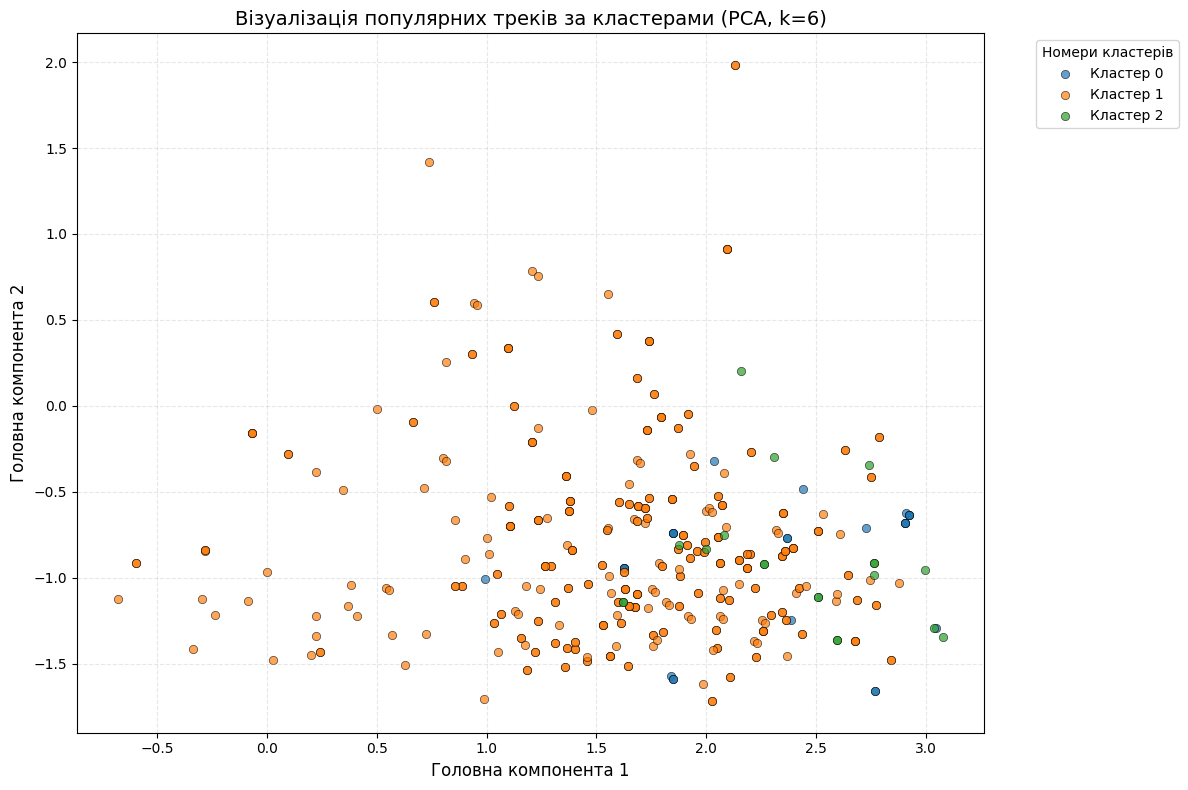

In [16]:
plt.figure(figsize=(12, 8))

unique_clusters = sorted(df_filtered['cluster'].unique())
cmap = plt.get_cmap('tab10') 

for i, cluster_id in enumerate(unique_clusters):
    cluster_subset = df_filtered[df_filtered['cluster'] == cluster_id]
    plt.scatter(
        cluster_subset['pca1'], 
        cluster_subset['pca2'], 
        label=f'Кластер {cluster_id}',
        color=cmap(i), 
        alpha=0.7, 
        edgecolors='k', 
        linewidth=0.5
    )

plt.title(f'Візуалізація популярних треків за кластерами (PCA, k={k_optimal})', fontsize=14)
plt.xlabel('Головна компонента 1', fontsize=12)
plt.ylabel('Головна компонента 2', fontsize=12)

plt.legend(title="Номери кластерів", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Аналіз кластерів
Можна помітити, що попри відносно високий відсоток поясненої дисперсії, кластери перемішалися докупи. Окрім цього, до вибірки потрапили лише 3 кластери, що означає, що усі пісні в інших кластерах мали популярність <85. Вже за цими даними можна зробити передбачення, що до кластерів 0-2 потрапили поп-пісні (або інші популярні пісні, які є достатньо схожими), проте для детальнішого аналізу візьмемо вибірки з кожного кластера.

In [17]:
import seaborn as sns

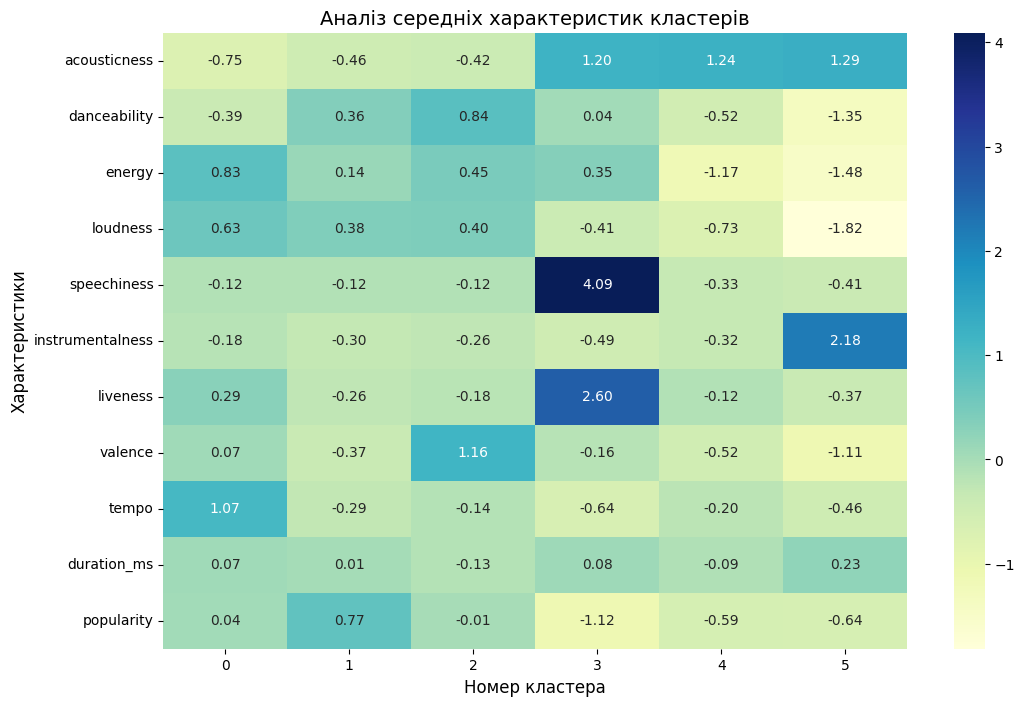

In [18]:
df_scaled['cluster'] = df['cluster']
cluster_analysis = df_scaled.groupby('cluster')[features].mean()

# 5.b. Побудова теплової карти (heatmap)
plt.figure(figsize=(12, 8))
# Стандартизуємо дані всередині таблиці для кращого контрасту кольорів
sns.heatmap(cluster_analysis.T, annot=True, cmap='YlGnBu', fmt=".2f")

plt.title('Аналіз середніх характеристик кластерів', fontsize=14)
plt.xlabel('Номер кластера', fontsize=12)
plt.ylabel('Характеристики', fontsize=12)
plt.show()

Судячи з heatmap, до кластеру 0 можна віднести рок та електроніку (судячи з loudness, energy, tempo), до кластеру 1 належать мейнстрім-пісні (поп, реп), до кластеру 2 танцювальна музика тощо. Перевіримо це на вибірці.

In [19]:
samples = []

for cluster_id in sorted(df['cluster'].unique()):
    cluster_sample = df[df['cluster'] == cluster_id][['track_name', 'artist_name', 'genre', 'cluster']].sample(5, random_state=7)
    samples.append(cluster_sample)

df_samples = pd.concat(samples)

print("Вибірка треків по кластерах:")
for cluster_id in sorted(df['cluster'].unique()):
    print(f"\n--- Кластер {cluster_id} ---")
    print(df_samples[df_samples['cluster'] == cluster_id][['track_name', 'artist_name', 'genre']].to_string(index=False))

Вибірка треків по кластерах:

--- Кластер 0 ---
                            track_name  artist_name      genre
                          Doubt Me Now Cody Johnson    Country
Take Back Home Girl (feat. Tori Kelly)   Chris Lane        Pop
                     Big Riddim Monsta  12th Planet Electronic
                          This Morning Picture This       Folk
                        It's Only Life    The Shins      Indie

--- Кластер 1 ---
     track_name  artist_name   genre
About the Money         T.I.     Pop
     Gravel Pit Wu-Tang Clan Hip-Hop
       Tomorrow  Chris Young    Rock
    CALLIGRAPHY         Saba Hip-Hop
 Whatchu Gon Do     Lil Baby     Rap

--- Кластер 2 ---
                                                                   track_name       artist_name            genre
                                                                 Private Room     Boosie Badazz          Hip-Hop
                                                    How She Threw It All Away The Style 

Бачимо, що здебільшого передбачення правдиві. Також варто зазначити кластер 3, що є найбільш виразним з усіх, і включає у себе треки без мелодії (стендапи, розмовні треки тощо).

In [20]:
import shutil
shutil.rmtree("./tmp/lab3")

# Висновки
У цій лабораторній роботі ми опанували методи кластеризації на прикладі Spotify Tracks Dataset, навчившись підбирати оптимальну кількість груп за допомогою методу ліктя та візуалізувати багатовимірні дані через PCA. Завдяки стандартизації та алгоритму K-Means ми виділили чіткі музичні сегменти на основі таких ознак, як енергійність, темп та акустичність. Фінальний аналіз дозволив ідентифікувати специфічні кластери — від популярних танцювальних треків до спокійних інструментальних творів та розмовного контенту.